# SIF (Structured Insight Framework) with Exploratory Data Analysis for the Netflix Datase using the Star Schema Model -Aira

## 1. 🚀 DEFINE ANALYTICAL QUESTIONS 

### 1.  Performance (fact_weekly_performance)
- What defines a “hit”?
- Do top-ranked shows sustain or decay?

### 2.  Geography (dim_country)
- Do countries behave differently?
- Is there a Nordic pattern?

### 3. Time (dim_date)
- How long do shows stay relevant?
- Are there seasonal spikes?
  
### 4. Content (dim_show + dim_category)
- Films vs TV → which dominates?
- Which genres perform best?

## 📊 Define Metrics - Core KPI Layer for the Popularity of a show | Performance Score
semantic contract for all visuals

| Metric                | Definition                                      | Formula                                                  |
|---------------------|-----------------------------------------------|----------------------------------------------------------|
| Popularity / Performance Score | Combines rank and longevity into one score | (11 - weekly_rank) * log(1 + cumulative_weeks)           |
| Longevity           | Total time a show stays in Top 10             | max(cumulative_weeks_in_top_10)                          |
| Average Rank        | Average ranking position over time            | mean(weekly_rank)                                        |
| Scale               | Total viewing volume                          | sum(weekly_views)                                        |
| Engagement Intensity| Views per week while in Top 10                | total_views / weeks_in_top10                             |

## 📊 EDA LAYER

In [92]:
import pandas as pd
import duckdb
from pathlib import Path   
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import seaborn as sns
import squarify

p = Path().resolve()

for i, parent in enumerate(p.parents):
    print(i, parent)

0 C:\Users\adelo\de25\Netflix_Analytics_DE_UX\eda
1 C:\Users\adelo\de25\Netflix_Analytics_DE_UX
2 C:\Users\adelo\de25
3 C:\Users\adelo
4 C:\Users
5 C:\


In [93]:
# Fix Path
BASE_DIR = Path().resolve().parents[1]   # ✅ correct level
MODEL_DIR = BASE_DIR / "data" / "processed" / "model"

print(MODEL_DIR)

C:\Users\adelo\de25\Netflix_Analytics_DE_UX\data\processed\model


In [94]:
# Validate the tables exist in the Path
print((MODEL_DIR / "dim_show.csv").exists())

True


In [95]:
# Register All Tables

con = duckdb.connect()

def register(table_name):
    path = (MODEL_DIR / table_name).as_posix()
    
    con.execute(f"""
    CREATE OR REPLACE VIEW {table_name.replace('.csv','')} AS 
    SELECT * FROM read_csv_auto('{path}');
    """)

tables = [
    "dim_show.csv",
    "dim_date.csv",
    "dim_country.csv",
    "dim_category.csv",
    "dim_genre.csv",
    "bridge_show_genre.csv",
    "fact_weekly_performance.csv",
    "fact_alltime.csv"
]

for t in tables:
    register(t)

In [96]:
# Sanity Check for tables

con.execute("SELECT COUNT(*) FROM dim_show").df()
con.execute("SELECT COUNT(*) FROM fact_weekly_performance").df()

,count_star()
0,458235


In [97]:
top_shows = con.execute("""
SELECT 
    s.show_title,
    SUM(f.performance_score) AS total_score,
    AVG(f.weekly_rank) AS avg_rank,
    MAX(f.cumulative_weeks_in_top_10) AS longevity,
    SUM(f.weekly_views) AS total_views

FROM fact_weekly_performance f
JOIN dim_show s 
    ON f.show_key = s.show_key

GROUP BY s.show_title
ORDER BY total_score DESC
LIMIT 20
""").df()

top_shows

,show_title,total_score,avg_rank,longevity,total_views
0,Stranger Things,60347.686325,5.547446,35,5.854600e+10
1,KPop Demon Hunters,45807.493005,4.428469,39,4.797050e+10
2,Squid Game,41013.313938,4.029566,43,5.685150e+10
3,Bridgerton,38789.932880,4.707680,49,4.544880e+10
4,Wednesday,32339.101712,4.052191,48,2.652270e+10
5,Manifest,26484.336093,5.358050,24,1.568000e+08
6,"Pablo Escobar, el patrón del mal",25774.231176,5.865342,102,NaN
7,Pasión de Gavilanes,24114.739528,5.626804,102,NaN
8,The Good Doctor,19669.019124,5.528933,26,1.938000e+08
9,Emily in Paris,17758.656170,4.762765,15,1.276260e+10


In [98]:
# Checks for top shows
top_shows.describe()

,total_score,avg_rank,longevity,total_views
count,20.000000,20.000000,20.000000,1.600000e+01
mean,24147.451837,4.917099,44.650000,1.846256e+10
std,13126.490224,0.593435,32.590401,2.127165e+10
min,12180.455634,3.874206,13.000000,3.000000e+07
25%,15427.510316,4.443379,22.000000,3.466350e+09
50%,17710.983861,4.949793,37.000000,8.051450e+09
75%,27948.027498,5.400771,50.250000,3.125422e+10
max,60347.686325,5.865342,127.000000,5.854600e+10


# Data Storytelling Overview (Timeframe: March 2025 - March 2026)

I will use this Metrics to show a story
| Metric                | What it Measures                          | Formula                                                  |
|---------------------|------------------------------------------|----------------------------------------------------------|
| **Performance Score** | Popularity adjusted for longevity        | `(11 - weekly_rank) * log(1 + cumulative_weeks)`         |
| **Longevity**         | Staying power in Top 10                  | `max(cumulative_weeks_in_top_10)`                        |
| **Average Rank**      | Consistency of ranking                   | `mean(weekly_rank)`                                      |
| **Scale**             | Total audience reach                     | `sum(weekly_views)`                                      |
| **Engagement Intensity** | Depth of engagement per week        | `total_views / weeks_in_top10`                           |

## 1. What makes a show in Netflix a hit?
Not every Netflix Top 10 title is successful in the same way. Some shows spike quickly and disappear, while others stay visible for many weeks. This analysis investigates whether short-term popularity or sustained engagement is the stronger signal of success.

In [99]:
hit_analysis_all_years = con.execute("""
SELECT
    s.show_title,
    s.category,

    -- Success / performance
    SUM(f.performance_score) AS performance_score,

    -- Longevity
    MAX(f.cumulative_weeks_in_top_10) AS weeks_in_top10,

    -- Popularity / rank quality
    AVG(f.weekly_rank) AS avg_rank,
    MIN(f.weekly_rank) AS best_rank,

    -- Scale
    SUM(f.weekly_views) AS total_views,

    -- Frequency in weekly country-level Top 10
    COUNT(*) AS appearances

FROM fact_weekly_performance f
JOIN dim_show s
    ON f.show_key = s.show_key

GROUP BY
    s.show_title,
    s.category

HAVING
    SUM(f.performance_score) IS NOT NULL
    AND MAX(f.cumulative_weeks_in_top_10) IS NOT NULL

ORDER BY performance_score DESC
LIMIT 10
""").df()

hit_analysis_all_years

,show_title,category,performance_score,weeks_in_top10,avg_rank,best_rank,total_views,appearances
0,Stranger Things,TV,60347.686325,35,5.547446,1,5.854600e+10,5933
1,KPop Demon Hunters,Films,45807.493005,39,4.428469,1,4.797050e+10,2803
2,Squid Game,TV,41013.313938,43,4.029566,1,5.685150e+10,3247
3,Bridgerton,TV,38789.932880,49,4.707680,1,4.544880e+10,3698
4,Wednesday,TV,32339.101712,48,4.052191,1,2.652270e+10,2510
5,Manifest,TV,26484.336093,24,5.358050,1,1.568000e+08,2913
6,"Pablo Escobar, el patrón del mal",TV,25774.231176,102,5.865342,1,NaN,1359
7,Pasión de Gavilanes,TV,24114.739528,102,5.626804,1,NaN,1455
8,The Good Doctor,TV,19669.019124,26,5.528933,1,1.938000e+08,2333
9,Emily in Paris,TV,17758.656170,15,4.762765,1,1.276260e+10,2213


In [100]:
# Only time limited from 2025 - 2026 | Version 1
hit_analysis = con.execute("""
SELECT
    s.show_title,
    s.category,

    SUM(f.performance_score) AS performance_score,
    MAX(f.cumulative_weeks_in_top_10) AS weeks_in_top10,
    AVG(f.weekly_rank) AS avg_rank,
    MIN(f.weekly_rank) AS best_rank,
    SUM(f.weekly_views) AS total_views,
    COUNT(*) AS appearances

FROM fact_weekly_performance f

JOIN dim_show s
    ON f.show_key = s.show_key

JOIN dim_date d
    ON f.date_key = d.date_key

WHERE d.week_start_date BETWEEN DATE '2025-03-01' AND DATE '2026-03-31'

GROUP BY
    s.show_title,
    s.category

ORDER BY performance_score DESC 

LIMIT 20
""").df()

hit_analysis

,show_title,category,performance_score,weeks_in_top10,avg_rank,best_rank,total_views,appearances
0,KPop Demon Hunters,Films,45807.493005,39,4.428469,1,4.797050e+10,2803
1,Stranger Things,TV,27681.672259,35,6.125981,1,5.854600e+10,2675
2,Wednesday,TV,16947.022226,48,4.170147,1,2.652270e+10,1293
3,Squid Game,TV,10510.324296,43,4.545455,1,2.462140e+10,957
4,Adolescence,TV,8818.489665,12,3.745000,1,1.271520e+10,800
5,Bridgerton,TV,8568.920900,49,3.978372,1,1.562030e+10,786
6,Ginny & Georgia,TV,5993.217920,13,5.317373,1,7.968400e+09,731
7,HIS & HERS,TV,5228.295521,9,3.516981,1,7.745000e+09,530
8,"Bon Appétit, Your Majesty",TV,4966.172647,12,4.619522,1,2.875200e+09,502
9,UNTAMED,TV,4620.015806,10,3.547667,1,6.838900e+09,493


In [101]:
recent_hits = con.execute("""
SELECT
    s.show_title,
    SUM(f.performance_score) AS performance_score,
    SUM(f.weekly_views) AS total_views

FROM fact_weekly_performance f
JOIN dim_show s ON f.show_key = s.show_key
JOIN dim_date d ON f.date_key = d.date_key

WHERE d.week_start_date BETWEEN DATE '2025-03-01' AND DATE '2026-03-31'

GROUP BY s.show_title
ORDER BY performance_score DESC
LIMIT 15
""").df()

recent_hits

,show_title,performance_score,total_views
0,KPop Demon Hunters,45807.493005,4.797050e+10
1,Stranger Things,27681.672259,5.854600e+10
2,Wednesday,16947.022226,2.652270e+10
3,Squid Game,10510.324296,2.462140e+10
4,Adolescence,8818.489665,1.271520e+10
5,Bridgerton,8568.920900,1.562030e+10
6,Ginny & Georgia,5993.217920,7.968400e+09
7,HIS & HERS,5228.295521,7.745000e+09
8,"Bon Appétit, Your Majesty",4966.172647,2.875200e+09
9,UNTAMED,4620.015806,6.838900e+09


C:\Users\adelo\AppData\Local\Temp\ipykernel_1144\1173691093.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20")


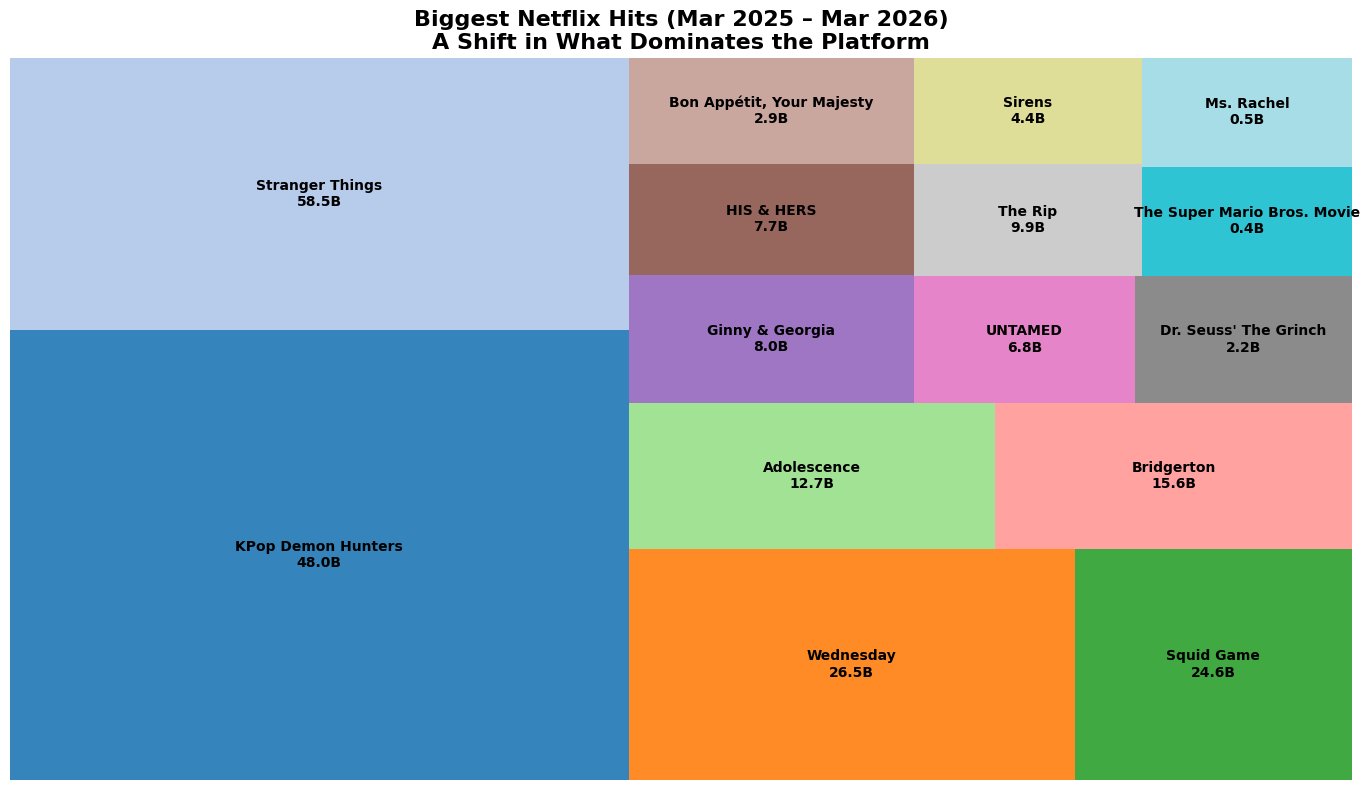

In [102]:
# ==============================
# PREP DATA (labels)
# ==============================
recent_hits = recent_hits.dropna(subset=["total_views", "performance_score"])
recent_hits = recent_hits.sort_values("performance_score", ascending=False)

labels = [
    f"{title}\n{views/1_000_000_000:.1f}B"
    for title, views in zip(recent_hits["show_title"], recent_hits["total_views"])
]

sizes = recent_hits["performance_score"]


# ==============================
# COLOR STRATEGY (HIGH CONTRAST)
# ==============================
cmap = plt.cm.get_cmap("tab20")
colors = [cmap(i) for i in np.linspace(0, 1, len(sizes))]


# ==============================
# PLOT TREEMAP
# ==============================
plt.figure(figsize=(14, 8))

squarify.plot(
    sizes=sizes,
    label=labels,
    color=colors,
    alpha=0.9,
    text_kwargs={"fontsize": 10, "weight": "bold"}
)

plt.title(
    "Biggest Netflix Hits (Mar 2025 – Mar 2026)\nA Shift in What Dominates the Platform",
    fontsize=16,
    weight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Why are these Top Shows a Hit? Why it changed?
| Metric                                       | Source                                  | Type       | Formula                                               | What It Means                                                                    |
| -------------------------------------------- | --------------------------------------- | ---------- | ----------------------------------------------------- | -------------------------------------------------------------------------------- |
| **Weeks in Top 10**                          | Raw data (`cumulative_weeks_in_top_10`) | Extracted  | `MAX(cumulative_weeks_in_top_10)`                     | Total number of weeks a show stayed in the Top 10 → **staying power / survival** |
| **Average Rank**                             | Derived from `weekly_rank`              | Engineered | `AVG(weekly_rank)`                                    | Average position in the Top 10 → **consistency of performance (lower = better)** |
| **Rank Volatility**                          | Derived from `weekly_rank`              | Engineered | `STDDEV(weekly_rank)`                                 | How much the ranking fluctuates → **stability vs spikes (lower = more stable)**  |
| **Total Views** *(optional but useful)*      | Raw (`weekly_views`)                    | Aggregated | `SUM(weekly_views)`                                   | Total audience reach → **scale of success**                                      |
| **Engagement Intensity** *(your key metric)* | Derived                                 | Engineered | `SUM(weekly_views) / MAX(cumulative_weeks_in_top_10)` | Views per week while trending → **how strongly people watch it each week**       |

Do shows win by lasting longer, or by being watched more intensely?



In [103]:
# Build the dataset to explain why those top shows are hits 
why_data = con.execute("""
SELECT
    s.show_title,

    -- Keep if you still want it later
    SUM(f.performance_score) AS performance_score,

    -- Core drivers
    MAX(f.cumulative_weeks_in_top_10) AS weeks_in_top10,
    SUM(f.weekly_views) AS total_views

FROM fact_weekly_performance f
JOIN dim_show s ON f.show_key = s.show_key
JOIN dim_date d ON f.date_key = d.date_key

WHERE d.week_start_date BETWEEN DATE '2025-03-01' AND DATE '2026-03-31'

GROUP BY s.show_title
ORDER BY performance_score DESC
LIMIT 10
""").df()

why_data

,show_title,performance_score,weeks_in_top10,total_views
0,KPop Demon Hunters,45807.493005,39,4.797050e+10
1,Stranger Things,27681.672259,35,5.854600e+10
2,Wednesday,16947.022226,48,2.652270e+10
3,Squid Game,10510.324296,43,2.462140e+10
4,Adolescence,8818.489665,12,1.271520e+10
5,Bridgerton,8568.920900,49,1.562030e+10
6,Ginny & Georgia,5993.217920,13,7.968400e+09
7,HIS & HERS,5228.295521,9,7.745000e+09
8,"Bon Appétit, Your Majesty",4966.172647,12,2.875200e+09
9,UNTAMED,4620.015806,10,6.838900e+09


In [104]:
# They have different scales so must be normalized

why_data["performance_norm"] = why_data["performance_score"] / why_data["performance_score"].max()
why_data["longevity_norm"] = why_data["weeks_in_top10"] / why_data["weeks_in_top10"].max()
why_data["engagement_intensity"] = (why_data["total_views"] / why_data["weeks_in_top10"])

In [105]:
# Create engagement intensity first
why_data["engagement_intensity"] = (
    why_data["total_views"] / why_data["weeks_in_top10"]
)

# Normalize both metrics
why_data["engagement_norm"] = (
    why_data["engagement_intensity"] / why_data["engagement_intensity"].max()
)

why_data["longevity_norm"] = (
    why_data["weeks_in_top10"] / why_data["weeks_in_top10"].max()
)

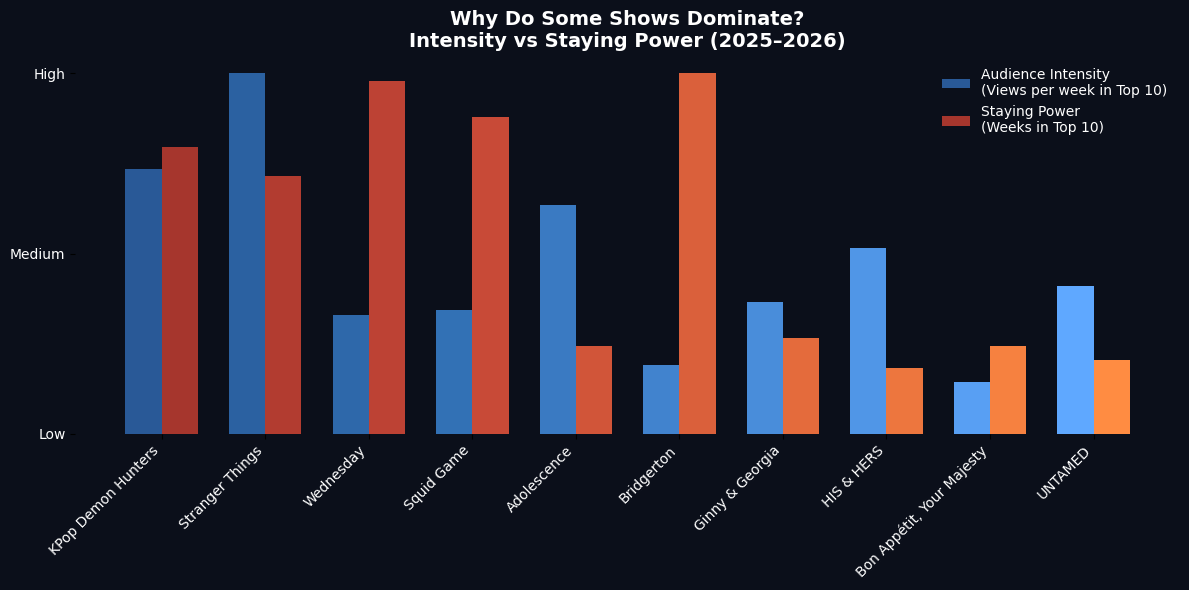

In [106]:
# Gradient for Intensity (blue)
intensity_cmap = LinearSegmentedColormap.from_list(
    "intensity",
    ["#1f3b73", "#2f6db0", "#5fa8ff"]
)

# Gradient for Longevity (orange/red)
longevity_cmap = LinearSegmentedColormap.from_list(
    "longevity",
    ["#7a1f1f", "#c44536", "#ff8c42"]
)

intensity_colors = intensity_cmap(
    np.linspace(0.3, 1, len(why_data))
)

longevity_colors = longevity_cmap(
    np.linspace(0.3, 1, len(why_data))
)

plt.figure(figsize=(12,6), facecolor="#0b0f1a")
ax = plt.gca()
ax.set_facecolor("#0b0f1a")

labels = why_data["show_title"]
x = np.arange(len(labels))
width = 0.35

plt.bar(
    x - width/2,
    why_data["engagement_norm"],
    width,
    color=intensity_colors,
    label="Audience Intensity\n(Views per week in Top 10)"
)

plt.bar(
    x + width/2,
    why_data["longevity_norm"],
    width,
    color=longevity_colors,
    label="Staying Power\n(Weeks in Top 10)"
)

# X-axis
plt.xticks(x, labels, rotation=45, ha="right", color="white")

# Y-axis (your improved version)
plt.yticks([0, 0.5, 1], ["Low", "Medium", "High"], color="white")

# Remove axis label (cleaner)
plt.ylabel("")

# Title
plt.title(
    "Why Do Some Shows Dominate?\n"
    "Intensity vs Staying Power (2025–2026)",
    fontsize=14,
    weight="bold",
    color="white"
)

# Legend
legend = plt.legend(facecolor="#0b0f1a", edgecolor="none")
for text in legend.get_texts():
    text.set_color("white")

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## NEW “HOW SHOWS WINS IN NETFLIX” PERSPECTIVE
- Consistency (Ranking Stability)
- How stable a show’s ranking is week-to-week

| Type           | Example         | Why it wins           |
| -------------- | --------------- | --------------------- |
| 🔴 Blockbuster | Stranger Things | High intensity        |
| 🟢 Evergreen   | Peppa Pig       | Long-term consistency |
| 🔵 Balanced    | Bridgerton      | Both                  |

---

| **Blockbuster (Hype-Driven)**             | **Evergreen (Habit-Driven)**                   |
| ----------------------------------------- | ---------------------------------------------- |
| High spike in views at release            | Steady, consistent views over time             |
| Strong initial demand                     | Lower but stable demand                        |
| Short lifespan in Top 10                  | Long lifespan in Top 10                        |
| Driven by hype and trends                 | Driven by repetition and routine               |
| Typically watched once (binge)            | Frequently rewatched                           |
| Audience drops after peak                 | Audience remains stable                        |
| Examples: *Stranger Things*, *Squid Game* | Examples: *Peppa Pig*, *Lottie Dottie Chicken* |

#### Evergreen
```
ORDER BY weeks_in_top10 DESC
```

#### Blockbusters
```
ORDER BY performance_score DESC
```

In [107]:
# build dataset to show consistency | votality

consistency_data = con.execute("""
SELECT
    s.show_title,

    MAX(f.cumulative_weeks_in_top_10) AS weeks_in_top10,
    AVG(f.weekly_rank) AS avg_rank,
    STDDEV(f.weekly_rank) AS rank_volatility

FROM fact_weekly_performance f
JOIN dim_show s ON f.show_key = s.show_key
JOIN dim_date d ON f.date_key = d.date_key

WHERE d.week_start_date BETWEEN DATE '2025-03-01' AND DATE '2026-03-31'

GROUP BY s.show_title
ORDER BY weeks_in_top10 DESC
LIMIT 20
""").df()

consistency_data

,show_title,weeks_in_top10,avg_rank,rank_volatility
0,Lottie Dottie Chicken,126,8.128205,1.360717
1,Peppa Pig,111,8.276923,1.375087
2,Kitty Kotty,87,8.166667,1.319479
3,Shrek,81,7.957672,1.731531
4,Mai,75,7.684211,2.080869
5,Paw Patrol: The Movie,55,7.829016,1.807619
6,Ms. Rachel,51,7.875576,1.742871
7,Bridgerton,49,3.978372,3.208792
8,Dr. Seuss' The Grinch,48,4.436508,2.855054
9,Wednesday,48,4.170147,3.026785


In [108]:
# Invert volatility (so higher = better)
consistency_data["consistency_score"] = 1 / (1 + consistency_data["rank_volatility"])

# Normalize
consistency_data["consistency_norm"] = (
    consistency_data["consistency_score"] / consistency_data["consistency_score"].max()
)

consistency_data["longevity_norm"] = (
    consistency_data["weeks_in_top10"] / consistency_data["weeks_in_top10"].max()
)

In [109]:
# Thresholds (simple + interpretable)
intensity_threshold = why_data["engagement_norm"].median()
longevity_threshold = why_data["longevity_norm"].median()

def classify(row):
    if row["engagement_norm"] >= intensity_threshold and row["longevity_norm"] < longevity_threshold:
        return "Blockbuster"
    elif row["longevity_norm"] >= longevity_threshold and row["engagement_norm"] < intensity_threshold:
        return "Evergreen"
    else:
        return "Balanced"

why_data["type"] = why_data.apply(classify, axis=1)

blockbuster = why_data[why_data["type"] == "Blockbuster"]
evergreen = why_data[why_data["type"] == "Evergreen"]

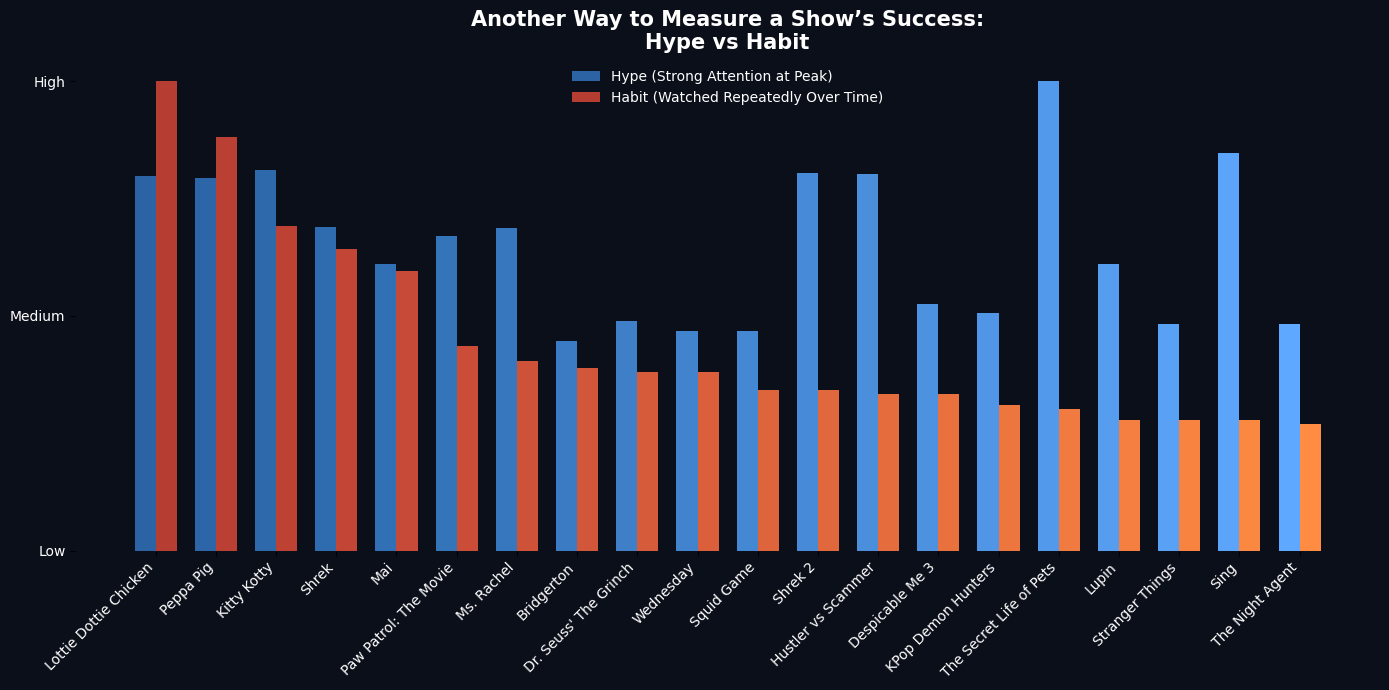

In [110]:
labels = consistency_data["show_title"]
x = np.arange(len(labels))
width = 0.35

# ==============================
# GRADIENT COLORS
# ==============================

# Blue gradient (Hype)
hype_cmap = LinearSegmentedColormap.from_list(
    "hype",
    ["#1f3b73", "#2f6db0", "#5fa8ff"]
)

# Orange gradient (Habit)
habit_cmap = LinearSegmentedColormap.from_list(
    "habit",
    ["#7a1f1f", "#c44536", "#ff8c42"]
)

hype_colors = hype_cmap(np.linspace(0.4, 1, len(labels)))
habit_colors = habit_cmap(np.linspace(0.4, 1, len(labels)))

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(14,7), facecolor="#0b0f1a")
ax = plt.gca()
ax.set_facecolor("#0b0f1a")

plt.bar(
    x - width/2,
    consistency_data["consistency_norm"],
    width,
    color=hype_colors,
    label="Hype (Strong Attention at Peak)"
)

plt.bar(
    x + width/2,
    consistency_data["longevity_norm"],
    width,
    color=habit_colors,
    label="Habit (Watched Repeatedly Over Time)"
)

# X axis
plt.xticks(x, labels, rotation=45, ha="right", color="white")

# Y axis
plt.yticks([0, 0.5, 1], ["Low", "Medium", "High"], color="white")
plt.ylabel("")

# Title
plt.title(
    "Another Way to Measure a Show’s Success:\nHype vs Habit",
    fontsize=15,
    weight="bold",
    color="white"
)

# Legend
legend = plt.legend(facecolor="#0b0f1a", edgecolor="none")
for text in legend.get_texts():
    text.set_color("white")

# Remove borders
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## Data Storytelling Christophe Marketing Skills Idea

In [111]:
# --- Define curated show groups ---
blockbuster_shows = [
    "K-pop Demon Hunters",
    "Stranger Things",
    "Wednesday",
    "Squid Game"
]

evergreen_shows = [
    "Lottie Dottie Chicken",
    "Peppa Pig",
    "Kitty Catty"
]

In [112]:
query = """
SELECT 
    s.show_title,
    AVG(f.performance_score) AS avg_intensity,   -- hype proxy
    MAX(f.cumulative_weeks_in_top_10) AS longevity -- staying power
FROM fact_weekly_performance f
JOIN dim_show s ON f.show_key = s.show_key
WHERE s.show_title IN ({})
GROUP BY s.show_title
"""

# Format query safely
all_shows = blockbuster_shows + evergreen_shows
formatted_list = ", ".join([f"'{s}'" for s in all_shows])

df = con.execute(query.format(formatted_list)).df()

In [113]:
df["intensity_norm"] = df["avg_intensity"] / df["avg_intensity"].max()
df["longevity_norm"] = df["longevity"] / df["longevity"].max()

In [114]:
def classify(show):
    if show in blockbuster_shows:
        return "Blockbuster"
    else:
        return "Evergreen"

df["type"] = df["show_title"].apply(classify)

In [115]:
query = f"""
SELECT 
    s.show_title,
    COALESCE(s.season_title, 'No Season') AS season,

    -- Retention
    MAX(f.cumulative_weeks_in_top_10) AS weeks_in_top10,

    -- Popularity
    SUM(f.performance_score) AS performance_score

FROM fact_weekly_performance f
JOIN dim_show s ON f.show_key = s.show_key

WHERE s.show_title IN ({formatted_list})

GROUP BY s.show_title, s.season_title
"""

In [116]:
df = con.execute(query).df()

df["label"] = (
    df["show_title"] + " (" + df["season"] + ")\n"
    + df["weeks_in_top10"].astype(str) + " weeks | "
    + df["performance_score"].astype(int).astype(str)
)

In [117]:
df = df.sort_values("performance_score", ascending=False)

df = df.groupby("show_title").head(1)

In [118]:
df["intensity_norm"] = df["performance_score"] / df["performance_score"].max()
df["longevity_norm"] = df["weeks_in_top10"] / df["weeks_in_top10"].max()

In [119]:
def classify(show):
    if show in blockbuster_shows:
        return "Blockbuster"
    elif show in evergreen_shows:
        return "Evergreen"
    else:
        return "Other"

df["type"] = df["show_title"].apply(classify)

## 2B. With Balanced | KPop Demon Hunters

In [120]:
# --- Define curated show groups ---

blockbuster_shows = [
    "Stranger Things",
    "Wednesday",
    "Squid Game"
]

balanced_shows = [
    "KPop Demon Hunters"
]

evergreen_shows = [
    "Lottie Dottie Chicken",
    "Peppa Pig",
    "Kitty Catty"
]

all_shows = blockbuster_shows + balanced_shows + evergreen_shows

all_shows

['Stranger Things',
 'Wednesday',
 'Squid Game',
 'KPop Demon Hunters',
 'Lottie Dottie Chicken',
 'Peppa Pig',
 'Kitty Catty']

In [121]:
formatted_list = ", ".join([f"'{show}'" for show in all_shows])


formatted_list

"'Stranger Things', 'Wednesday', 'Squid Game', 'KPop Demon Hunters', 'Lottie Dottie Chicken', 'Peppa Pig', 'Kitty Catty'"

In [122]:
query = f"""
SELECT 
    s.show_title,
    COALESCE(s.season_title, 'No Season') AS season,

    -- Hype / popularity proxy
    SUM(f.performance_score) AS performance_score,

    -- Retention / longevity proxy
    MAX(f.cumulative_weeks_in_top_10) AS weeks_in_top10,

    -- Optional average intensity
    AVG(f.performance_score) AS avg_intensity

FROM fact_weekly_performance f
JOIN dim_show s 
    ON f.show_key = s.show_key

WHERE s.show_title IN ({formatted_list})

GROUP BY 
    s.show_title,
    s.season_title
"""


query

"\nSELECT \n    s.show_title,\n    COALESCE(s.season_title, 'No Season') AS season,\n\n    -- Hype / popularity proxy\n    SUM(f.performance_score) AS performance_score,\n\n    -- Retention / longevity proxy\n    MAX(f.cumulative_weeks_in_top_10) AS weeks_in_top10,\n\n    -- Optional average intensity\n    AVG(f.performance_score) AS avg_intensity\n\nFROM fact_weekly_performance f\nJOIN dim_show s \n    ON f.show_key = s.show_key\n\nWHERE s.show_title IN ('Stranger Things', 'Wednesday', 'Squid Game', 'KPop Demon Hunters', 'Lottie Dottie Chicken', 'Peppa Pig', 'Kitty Catty')\n\nGROUP BY \n    s.show_title,\n    s.season_title\n"

In [123]:
df = con.execute(query).df()

df = (
    df.sort_values("performance_score", ascending=False)
      .groupby("show_title", as_index=False)
      .head(1)
)


df

,show_title,season,performance_score,weeks_in_top10,avg_intensity
4,KPop Demon Hunters,No Season,45807.493005,39,16.342309
3,Squid Game,Squid Game: Season 1,24925.307995,43,14.129993
13,Wednesday,Wednesday: Season 1,22512.389673,48,13.058231
9,Stranger Things,Stranger Things 4,21140.054183,35,12.882422
7,Lottie Dottie Chicken,Lottie Dottie Chicken: 2ª temporada,1850.008090,126,14.682604
10,Peppa Pig,Peppa Pig: Season 6,1531.161727,111,9.629948


In [124]:
def classify_show(show):
    if show in blockbuster_shows:
        return "Blockbuster"
    elif show in balanced_shows:
        return "Balanced"
    elif show in evergreen_shows:
        return "Evergreen"
    else:
        return "Other"

df["type"] = df["show_title"].apply(classify_show)

df

,show_title,season,performance_score,weeks_in_top10,avg_intensity,type
4,KPop Demon Hunters,No Season,45807.493005,39,16.342309,Balanced
3,Squid Game,Squid Game: Season 1,24925.307995,43,14.129993,Blockbuster
13,Wednesday,Wednesday: Season 1,22512.389673,48,13.058231,Blockbuster
9,Stranger Things,Stranger Things 4,21140.054183,35,12.882422,Blockbuster
7,Lottie Dottie Chicken,Lottie Dottie Chicken: 2ª temporada,1850.008090,126,14.682604,Evergreen
10,Peppa Pig,Peppa Pig: Season 6,1531.161727,111,9.629948,Evergreen


In [125]:
df["hype_norm"] = df["performance_score"] / df["performance_score"].max()
df["longevity_norm"] = df["weeks_in_top10"] / df["weeks_in_top10"].max()

In [126]:
def create_label(row):
    if row["type"] == "Blockbuster":
        title = f'{row["show_title"]} ({row["season"]})'
    else:
        title = row["show_title"]

    return (
        f"{title}\n"
        f'{int(row["weeks_in_top10"])}w | {int(row["performance_score"])}'
    )

df["label"] = df.apply(create_label, axis=1)

In [127]:
color_map = {
    "Blockbuster": "#e63946",  # red
    "Balanced": "#f4a261",     # orange
    "Evergreen": "#457b9d"     # blue
}

df["color"] = df["type"].map(color_map)

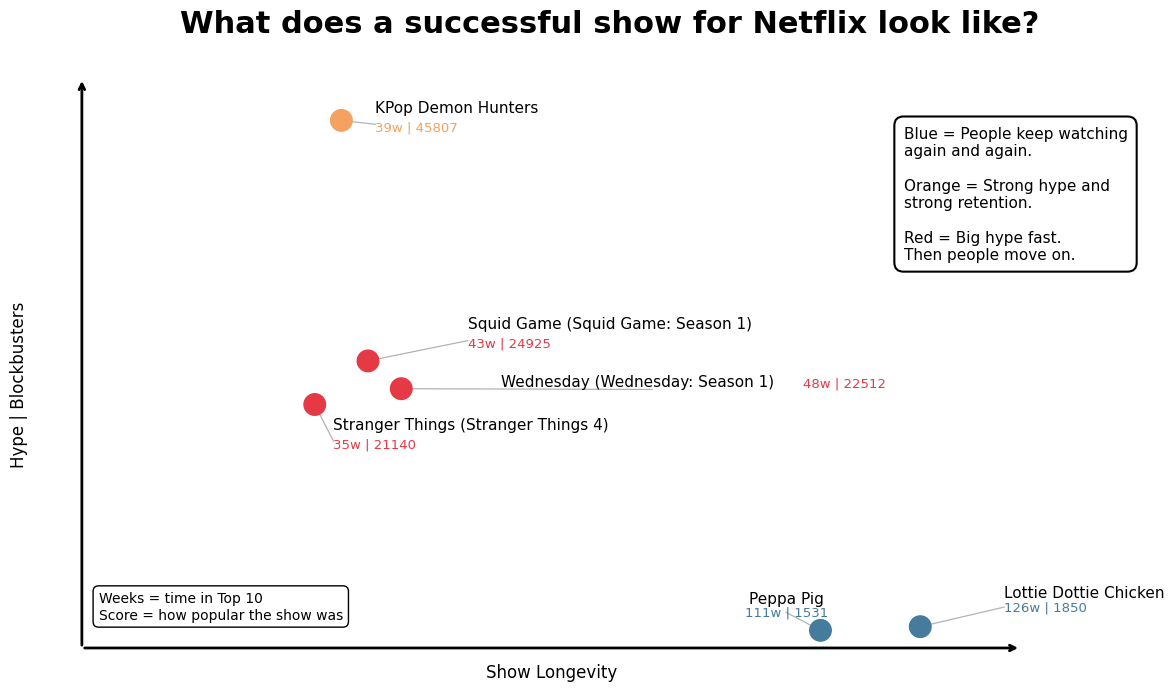

In [128]:
# =========================================================
# PLOT
# =========================================================
fig, ax = plt.subplots(figsize=(12, 7))

# -------------------------
# SCATTER
# -------------------------
ax.scatter(
    df["longevity_norm"],
    df["hype_norm"],
    c=df["color"],
    s=240,
    zorder=3
)

# -------------------------
# FIXED LABEL POSITIONS
# generous spacing
# x_title, y_title = show title
# x_sub, y_sub     = weeks | score
# -------------------------
label_positions = {
    "KPop Demon Hunters": {
        "x_title": 0.35, "y_title": 1.01,
        "x_sub":   0.35, "y_sub":   0.975,
        "ha_title": "left", "ha_sub": "left"
    },

    "Squid Game": {
        "x_title": 0.46, "y_title": 0.60,
        "x_sub":   0.46, "y_sub":   0.565,
        "ha_title": "left", "ha_sub": "left"
    },

    # Wednesday numbers placed BESIDE the title
    "Wednesday": {
        "x_title": 0.50, "y_title": 0.49,
        "x_sub":   0.86, "y_sub":   0.49,
        "ha_title": "left", "ha_sub": "left"
    },

    "Stranger Things": {
        "x_title": 0.30, "y_title": 0.41,
        "x_sub":   0.30, "y_sub":   0.375,
        "ha_title": "left", "ha_sub": "left"
    },

    "Peppa Pig": {
        "x_title": 0.84, "y_title": 0.08,
        "x_sub":   0.84, "y_sub":   0.055,
        "ha_title": "center", "ha_sub": "center"
    },

    "Lottie Dottie Chicken": {
        "x_title": 1.10, "y_title": 0.09,
        "x_sub":   1.10, "y_sub":   0.065,
        "ha_title": "left", "ha_sub": "left"
    },

    "Kitty Catty": {
        "x_title": 0.98, "y_title": 0.045,
        "x_sub":   0.98, "y_sub":   0.020,
        "ha_title": "left", "ha_sub": "left"
    }
}

# -------------------------
# LABELS + CONNECTOR LINES
# -------------------------
for row in df.itertuples():
    x = row.longevity_norm
    y = row.hype_norm

    label_main = row.label.split("\n")[0]
    label_sub = row.label.split("\n")[1]

    spec = label_positions.get(
        row.show_title,
        {
            "x_title": x + 0.03, "y_title": y + 0.03,
            "x_sub":   x + 0.03, "y_sub":   y + 0.005,
            "ha_title": "left", "ha_sub": "left"
        }
    )

    x_title = spec["x_title"]
    y_title = spec["y_title"]
    x_sub = spec["x_sub"]
    y_sub = spec["y_sub"]
    ha_title = spec["ha_title"]
    ha_sub = spec["ha_sub"]

    # Connector line to center of the label block
    x_mid = (x_title + x_sub) / 2
    y_mid = (y_title + y_sub) / 2

    ax.plot(
        [x, x_mid],
        [y, y_mid],
        color="gray",
        linewidth=0.9,
        alpha=0.6,
        zorder=2
    )

    # Show title
    ax.text(
        x_title,
        y_title,
        label_main,
        fontsize=11,
        color="black",
        ha=ha_title,
        va="bottom"
    )

    # Weeks | score
    ax.text(
        x_sub,
        y_sub,
        label_sub,
        fontsize=9.5,
        color=row.color,
        ha=ha_sub,
        va="bottom"
    )

# -------------------------
# AXIS ARROWS
# -------------------------
ax.annotate(
    "",
    xy=(1.12, 0),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle="->", linewidth=2, color="black")
)

ax.annotate(
    "",
    xy=(0, 1.08),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle="->", linewidth=2, color="black")
)

# -------------------------
# TEXT BOXES
# -------------------------
ax.text(
    0.98, 0.99,
    "Blue = People keep watching\nagain and again.\n\n"
    "Orange = Strong hype and\nstrong retention.\n\n"
    "Red = Big hype fast.\nThen people move on.",
    fontsize=11,
    ha="left",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="white",
        edgecolor="black",
        linewidth=1.5
    )
)

ax.text(
    0.02, 0.05,
    "Weeks = time in Top 10\nScore = how popular the show was",
    fontsize=10,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="black",
        linewidth=1
    )
)

# -------------------------
# AXIS LABELS
# -------------------------
ax.text(
    0.56, -0.055,
    "Show Longevity",
    fontsize=12,
    ha="center"
)

ax.text(
    -0.075, 0.50,
    "Hype | Blockbusters",
    fontsize=12,
    rotation=90,
    va="center",
    ha="center"
)

# -------------------------
# TITLE
# -------------------------
ax.set_title(
    "What does a successful show for Netflix look like?",
    fontsize=22,
    fontweight="bold",
    pad=18
)

# -------------------------
# CLEAN AXIS
# -------------------------
ax.set_xlim(-0.02, 1.28)
ax.set_ylim(-0.02, 1.12)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## 5. Pie Chart Family Genre Share of SHows


In [129]:
kids_genres = [
    'family',
    'animation',
    'adventure',
    'comedy',
    'music'
]

## A. Just Family Genre

In [130]:
family_df = con.execute("""
WITH show_classification AS (
    SELECT
        show_key,
        MAX(
            CASE 
                WHEN LOWER(genre) LIKE '%family%' THEN 1
                ELSE 0
            END
        ) AS is_family
    FROM bridge_show_genre
    GROUP BY show_key
)

SELECT
    CASE 
        WHEN is_family = 1 THEN 'Family'
        ELSE 'Other'
    END AS category,
    COUNT(*) AS show_count
FROM show_classification
GROUP BY category
""").df()

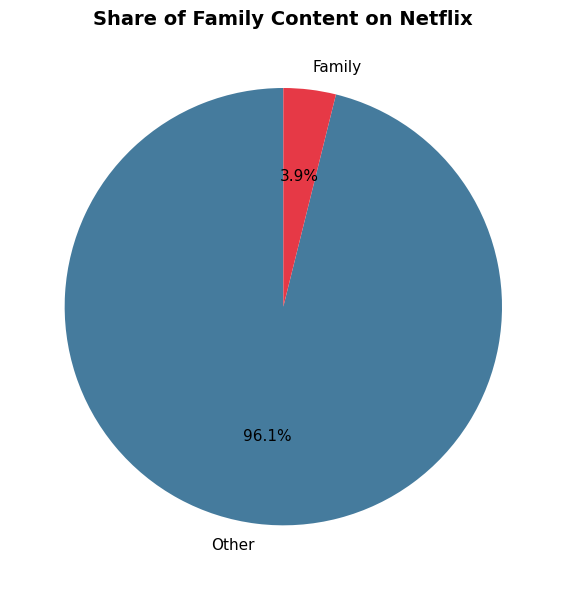

In [131]:
labels = family_df["category"]
sizes = family_df["show_count"]

colors = ["#457b9d", "#e63946"]  # blue = family, red = other

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 11}
)

plt.title(
    "Share of Family Content on Netflix",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()
plt.show()

## 6A. High Retention Shows 

In [132]:
high_retention_df = con.execute(f"""
WITH show_retention AS (
    SELECT
        s.show_key,
        s.show_title,
        MAX(f.cumulative_weeks_in_top_10) AS weeks
    FROM fact_weekly_performance f
    JOIN dim_show s ON f.show_key = s.show_key
    GROUP BY s.show_key, s.show_title
),

top_shows AS (
    SELECT *
    FROM show_retention
    ORDER BY weeks DESC
    LIMIT 20
),

classified AS (
    SELECT
        t.show_key,
        t.show_title,
        MAX(
            CASE 
                WHEN LOWER(b.genre) IN ({", ".join([f"'{g}'" for g in kids_genres])})
                THEN 1 ELSE 0
            END
        ) AS is_kids
    FROM top_shows t
    JOIN bridge_show_genre b ON t.show_key = b.show_key
    GROUP BY t.show_key, t.show_title
)

SELECT
    CASE 
        WHEN is_kids = 1 THEN 'Kids Content'
        ELSE 'Other'
    END AS category,
    COUNT(*) AS show_count
FROM classified
GROUP BY category
""").df()

high_retention_df

,category,show_count
0,Other,4
1,Kids Content,16


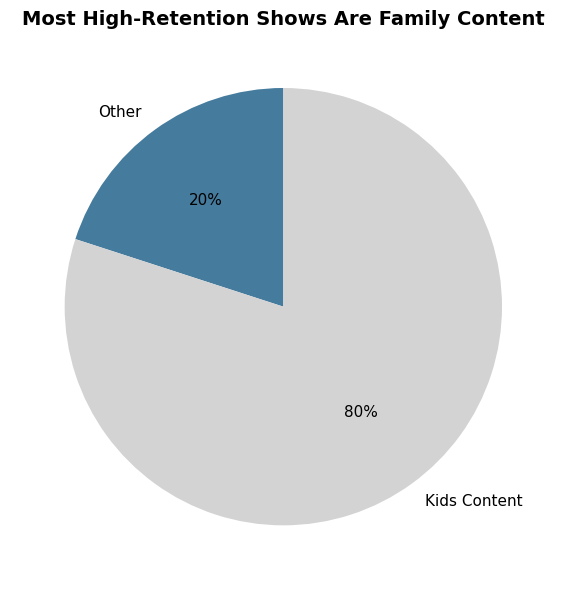

In [133]:
labels = high_retention_df["category"]
sizes = high_retention_df["show_count"]

colors = ["#457b9d", "#d3d3d3"]  # highlight family

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.0f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 11}
)

plt.title(
    "Most High-Retention Shows Are Family Content",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()
plt.show()

## 6B. High Retention Shows

In [134]:
genre_retention_df = con.execute("""
SELECT
    b.genre,
    AVG(f.cumulative_weeks_in_top_10) AS avg_weeks,
    COUNT(DISTINCT s.show_key) AS show_count
FROM fact_weekly_performance f
JOIN dim_show s ON f.show_key = s.show_key
JOIN bridge_show_genre b ON s.show_key = b.show_key

WHERE b.genre IS NOT NULL   -- 🔥 THIS FIX

GROUP BY b.genre
HAVING COUNT(DISTINCT s.show_key) > 5
ORDER BY avg_weeks DESC
""").df()

genre_retention_df

,genre,avg_weeks,show_count
0,Biography,5.595229,505
1,Animation,5.153903,926
2,Music,4.995818,201
3,Talk-Show,4.493308,24
4,Family,4.210783,494
5,Fantasy,4.196298,648
6,Musical,4.055923,70
7,Adventure,3.597963,1740
8,Drama,3.512682,5444
9,Crime,3.479745,2106


In [135]:
df = genre_retention_df.dropna(subset=["genre"])

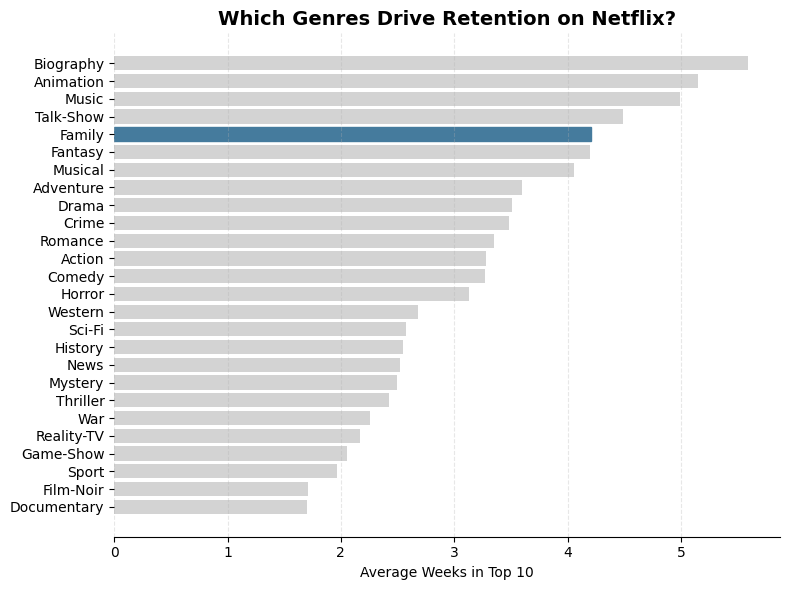

In [136]:
# Sort
df = genre_retention_df.sort_values("avg_weeks", ascending=True)

plt.figure(figsize=(8,6))

bars = plt.barh(
    df["genre"],
    df["avg_weeks"],
    color="#d3d3d3"
)

# Highlight FAMILY
for i, genre in enumerate(df["genre"]):
    if "family" in genre.lower():
        bars[i].set_color("#457b9d")

# Title
plt.title(
    "Which Genres Drive Retention on Netflix?",
    fontsize=14,
    weight="bold"
)

# Labels
plt.xlabel("Average Weeks in Top 10")

# Clean look
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.gca().spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.show()

## 6C. Pie Chart and Bar High Retention Shows

## 6D. High Retention FIlms

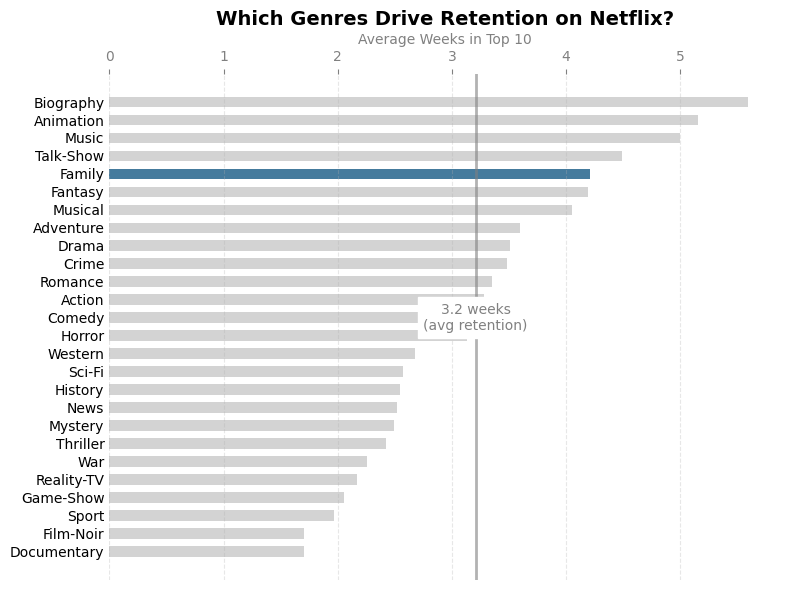

In [138]:
import matplotlib.pyplot as plt
import numpy as np

# Sort
df = genre_retention_df.sort_values("avg_weeks", ascending=True)

fig, ax = plt.subplots(figsize=(8,6))

# -------------------------
# COLORS
# -------------------------
colors = [
    "#457b9d" if "family" in g.lower() else "#d3d3d3"
    for g in df["genre"]
]

bars = ax.barh(
    df["genre"],
    df["avg_weeks"],
    color=colors,
    height=0.6
)

# -------------------------
# REFERENCE LINE (KEY PART)
# -------------------------
avg_value = df["avg_weeks"].mean()

ax.axvline(
    x=avg_value,
    color="grey",
    linestyle="-",
    linewidth=2,
    alpha=0.6
)

# -------------------------
# LABEL THE LINE
# -------------------------
ax.text(
    avg_value,
    len(df)/2,
    f"{avg_value:.1f} weeks\n(avg retention)",
    color="grey",
    ha="center",
    va="center",
    fontsize=10,
    backgroundcolor="white"
)

# -------------------------
# TITLE
# -------------------------
ax.set_title(
    "Which Genres Drive Retention on Netflix?",
    fontsize=14,
    weight="bold"
)

# -------------------------
# X AXIS (move to top like sample)
# -------------------------
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

ax.set_xlabel("Average Weeks in Top 10", color="grey")

# -------------------------
# CLEAN DESIGN
# -------------------------
ax.grid(axis="x", linestyle="--", alpha=0.3)

for spine in ["left", "right", "bottom", "top"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', colors='grey')

plt.tight_layout()
plt.show()

## 6e. High Retention Shows

In [139]:
genre_retention_df = con.execute("""
WITH show_level AS (
    SELECT
        s.show_key,
        s.show_title,
        s.season_title,
        LOWER(b.genre) AS genre,
        MAX(f.cumulative_weeks_in_top_10) AS weeks_in_top10
    FROM fact_weekly_performance f
    JOIN dim_show s ON f.show_key = s.show_key
    JOIN bridge_show_genre b ON s.show_key = b.show_key
    WHERE b.genre IS NOT NULL
    GROUP BY s.show_key, s.show_title, s.season_title, b.genre
)

SELECT
    genre,
    AVG(weeks_in_top10) AS avg_weeks,
    COUNT(*) AS show_count
FROM show_level
GROUP BY genre
HAVING COUNT(*) >= 10   -- reliability filter
ORDER BY avg_weeks DESC
""").df()

genre_retention_df

,genre,avg_weeks,show_count
0,animation,4.787257,926
1,talk-show,4.291667,24
2,adventure,4.243103,1740
3,family,4.218623,494
4,romance,4.172276,1753
5,drama,3.989530,5444
6,comedy,3.962607,3637
7,music,3.955224,201
8,action,3.943667,2645
9,crime,3.933523,2106


In [140]:
family_proof_df = con.execute("""
SELECT
    s.show_title,
    s.season_title,
    MAX(f.cumulative_weeks_in_top_10) AS weeks
FROM fact_weekly_performance f
JOIN dim_show s ON f.show_key = s.show_key
JOIN bridge_show_genre b ON s.show_key = b.show_key
WHERE LOWER(b.genre) = 'family'
GROUP BY s.show_key, s.show_title, s.season_title
ORDER BY weeks DESC
LIMIT 10
""").df()

family_proof_df

,show_title,season_title,weeks
0,Lottie Dottie Chicken,Lottie Dottie Chicken: 2ª temporada,126
1,Chiquititas,No Season,93
2,Ms. Rachel,Ms. Rachel: Season 1,51
3,Carinha de Anjo,Carinha de Anjo: Season 1,42
4,Reply 1988,Reply 1988: Season 1,39
5,As Aventuras de Poliana,As Aventuras de Poliana: Season 1,37
6,SpongeBob SquarePants,SpongeBob SquarePants: Season 9,33
7,Harry Potter and the Sorcerer's Stone,No Season,33
8,How the Grinch Stole Christmas,No Season,28
9,CoComelon,CoComelon: Season 1,28


In [141]:
kids_genres = [
    "family",
    "animation",
    "adventure",
    "comedy",
    "music"
]

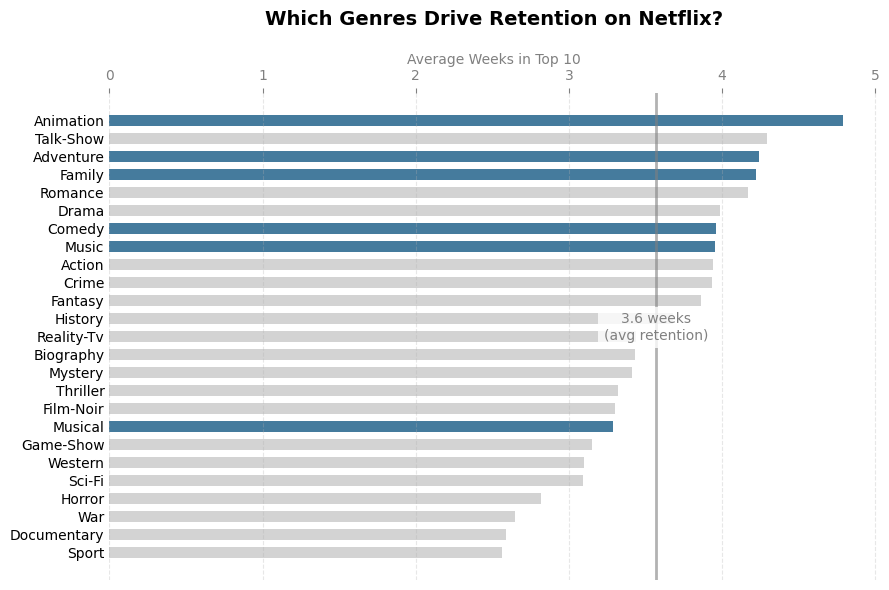

In [142]:
df = genre_retention_df.sort_values("avg_weeks", ascending=True)

fig, ax = plt.subplots(figsize=(9,6))

# -------------------------
# COLOR LOGIC (story-driven)
# -------------------------
colors = [
    "#457b9d" if any(k in g for k in kids_genres) else "#d3d3d3"
    for g in df["genre"]
]

bars = ax.barh(
    df["genre"].str.title(),
    df["avg_weeks"],
    color=colors,
    height=0.6
)

# -------------------------
# REFERENCE LINE (KEY INSIGHT)
# -------------------------
avg_value = df["avg_weeks"].mean()

ax.axvline(
    x=avg_value,
    color="grey",
    linestyle="-",
    linewidth=2,
    alpha=0.6
)

# Label the line
ax.text(
    avg_value,
    len(df)/2,
    f"{avg_value:.1f} weeks\n(avg retention)",
    ha="center",
    va="center",
    fontsize=10,
    color="grey",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8)
)

# -------------------------
# TITLE + SUBTITLE
# -------------------------
ax.set_title(
    "Which Genres Drive Retention on Netflix?",
    fontsize=14,
    weight="bold",
    pad=20
)

# -------------------------
# AXIS STYLE (Dataquest style)
# -------------------------
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_xlabel("Average Weeks in Top 10", color="grey")

# -------------------------
# CLEAN DESIGN
# -------------------------
ax.grid(axis="x", linestyle="--", alpha=0.3)

for spine in ["left", "right", "bottom", "top"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', colors='grey')

plt.tight_layout()
plt.show()

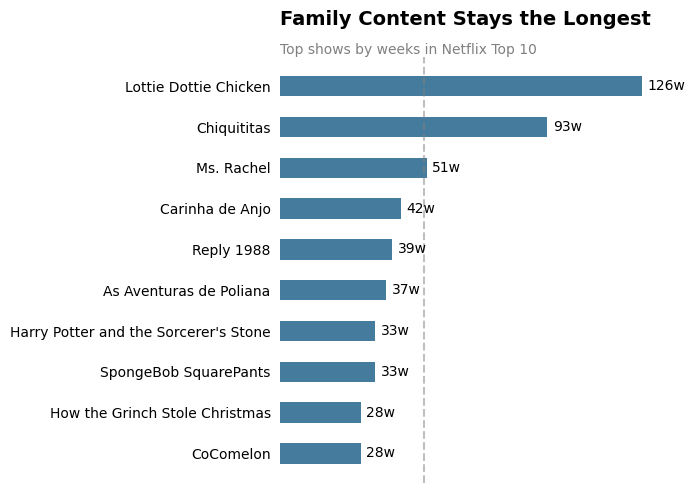

In [143]:
# Sort ascending for clean barh layout
df_plot = family_proof_df.sort_values("weeks")

fig, ax = plt.subplots(figsize=(7,5))

ax.barh(
    df_plot["show_title"],
    df_plot["weeks"],
    color="#457b9d",
    height=0.5
)

# Remove clutter
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(left=False, bottom=False)
ax.set_xticks([])

# Add values next to bars
for i, v in enumerate(df_plot["weeks"]):
    ax.text(v + 2, i, f"{v}w", va='center', fontsize=10)

# Title + subtitle
ax.text(
    0, len(df_plot) + 0.5,
    "Family Content Stays the Longest",
    fontsize=14,
    weight="bold"
)

ax.text(
    0, len(df_plot) - 0.2,
    "Top shows by weeks in Netflix Top 10",
    fontsize=10,
    color="gray"
)

ax.axvline(x=50, linestyle='--', color='gray', alpha=0.5)

plt.tight_layout()
plt.show()